# Linear Regression

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import pickle


## Definición del problema

>### Predecir el coste del seguro médico de una persona
>La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de datos los fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.


## Recopilación de datos

In [33]:
df = pd.read_csv('/workspaces/adamcn10-intro-ml/data/raw/medical_insurance_cost.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Análisis Descriptivo

In [34]:
df.shape

(1338, 7)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


##### Observaciones- Conclusiones
>- Vemos que es un set de datos de 1338 filas y 7 columnas sin valores nulos en ninguna de ellas.
>- De los datos que tenemos 3 son categóricos ('sex', 'smoker' y 'region') y el resto númericos ('age', 'bmi', 'children' y la variable objetivo 'charges')

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [37]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

##### Observaciones- Conclusiones
>- Vemos que la variable objetivo tiene practicamente un valor diferente para cada entrada menos uno, se podría tratar de una fila duplicada.
>- Bmi es la otra con más valores distintos, el resto de variables tienen unca cantidad lógica o reducida de valores.

## Limpieza de Datos

### Eliminación de duplicados

In [38]:
df.duplicated().sum()

np.int64(1)

>Vemos que hay un valor duplicado y por lo visto antes, solo podía haber una fila duplicada por la cantidad de primas diferentes que veiamos.
>Procederemos a eliminar esta fila duplicada con drop_duplicates

In [39]:
df.drop_duplicates(inplace=True)
df.shape

(1337, 7)

>Ahora el dataframe consta de 1337 filas diferentes y 7 columnas

## Eliminación de la información irrelevante

>La unica información que podría llegar a ser irrelevante es la de la columna 'region', pero dado que esto no es seguro y si que podría influir dejaré la eliminación de esta como un comentario y no se ejecutará.

In [40]:
#df.drop('region', inplace=True)

## Análisis de Variables

## Análisis de Variables Univariable

### Análisis de Variables Univariable Categórica

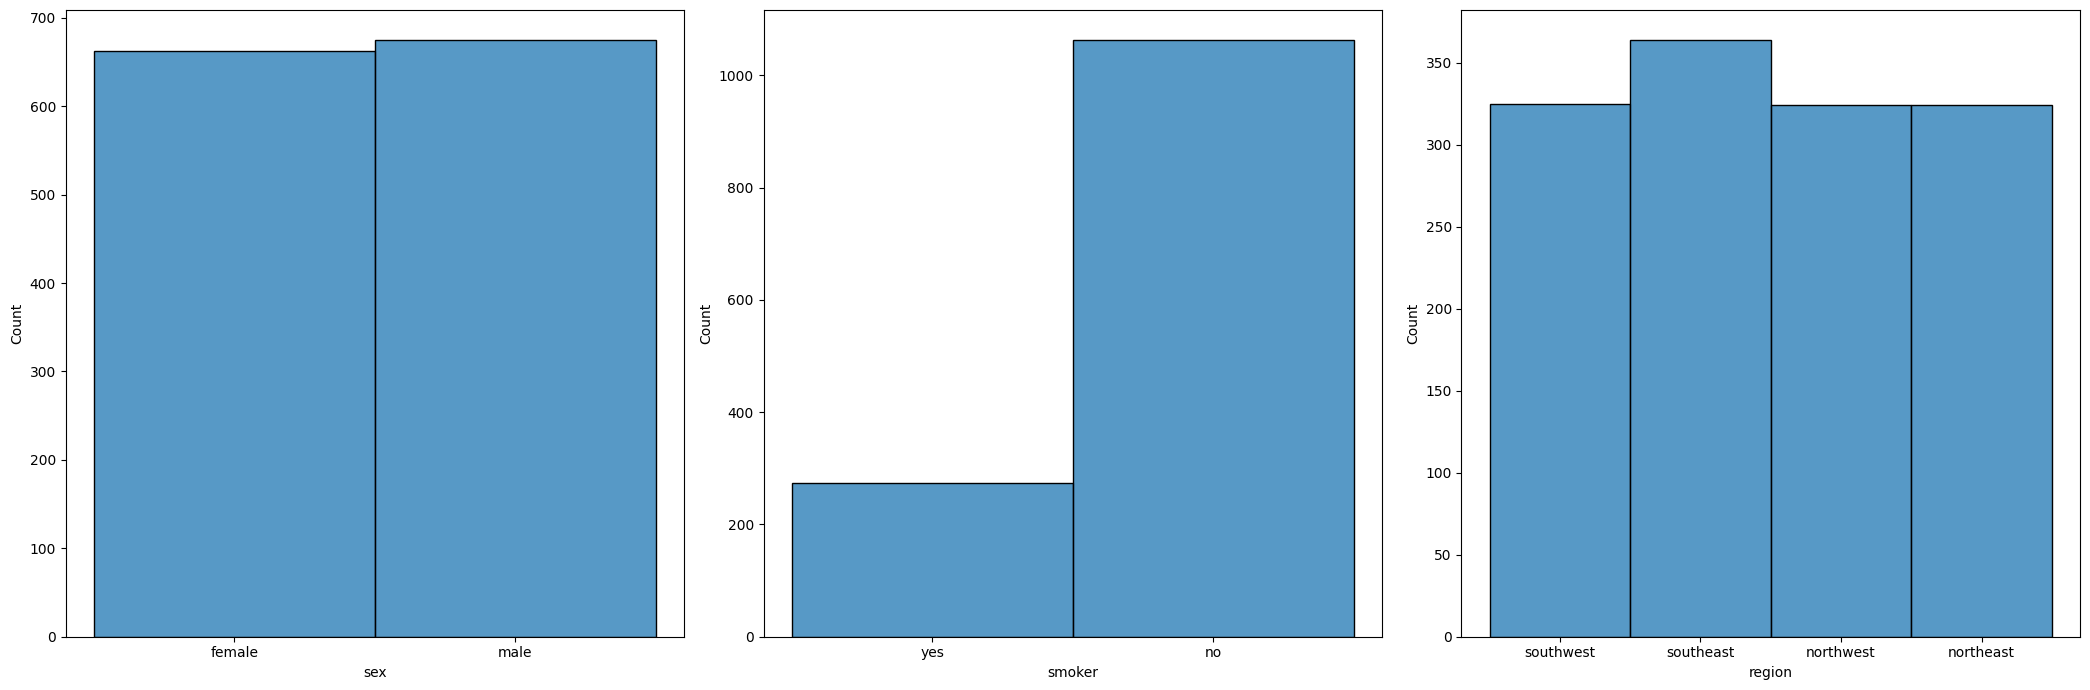

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(21,7))
sns.histplot(ax=axs[0], data=df, x="sex")
sns.histplot(ax=axs[1], data=df, x="smoker")
sns.histplot(ax=axs[2], data=df, x="region")
plt.tight_layout()
plt.show()

##### Observaciones - Conclusiones
> Vemos que los datos de sexo y región estan repartidos de manera bastante equitativa, en cambio, el hecho de fumar o no, hay mucha más gente no fumadora que sí.

### Análisis de Variables Univariable Numérico

<function matplotlib.pyplot.show(close=None, block=None)>

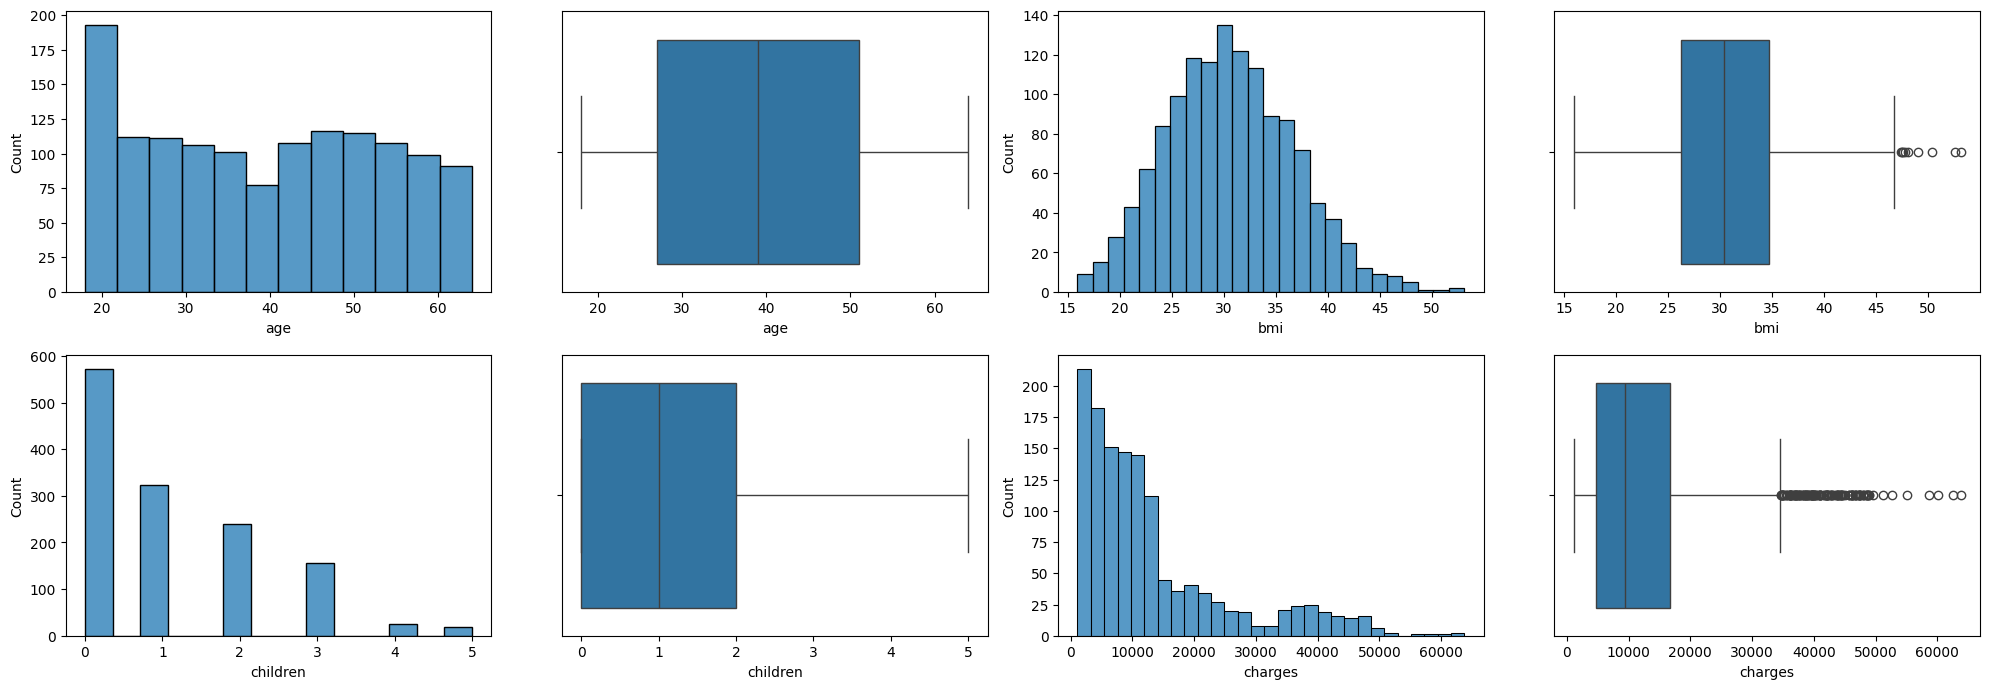

In [42]:
fig, axis = plt.subplots(2, 4, figsize=(20, 7))

sns.histplot(ax=axis[0, 0], data=df, x="age")
sns.boxplot(ax=axis[0, 1], data=df, x="age")
sns.histplot(ax=axis[0, 2], data=df, x="bmi")
sns.boxplot(ax=axis[0, 3], data=df, x="bmi")
sns.histplot(ax=axis[1, 0], data=df, x="children")
sns.boxplot(ax=axis[1, 1], data=df, x="children")
sns.histplot(ax=axis[1, 2], data=df, x="charges")
sns.boxplot(ax=axis[1, 3], data=df, x="charges")

plt.tight_layout()
plt.show

##### Observaciones - Conclusiones
>- age: La edad está bastante bien repartida pero con un pico en 20.
>- bmi: La distribución de bmi tiende a una distribución normal pero con una cola más larga por la derecha por lo que tienen algunos outliers.
>- children: Vemos una distribución decreciente, en cuantos más hijos menos casos encontramos.
>- charges: Parece que decrece desde los precios más bajos con un repunte entre los 35000 y los 50000.

### Análisis de Variable Multivariable

#### Análisis Numérico - Numérico

>Generamos las correlaciones

In [43]:
corr_charges_age = df[["charges", "age"]].corr()
corr_charges_bmi = df[["charges", "bmi"]].corr()
corr_charges_children = df[["charges", "children"]].corr()

>Generamos los graficos

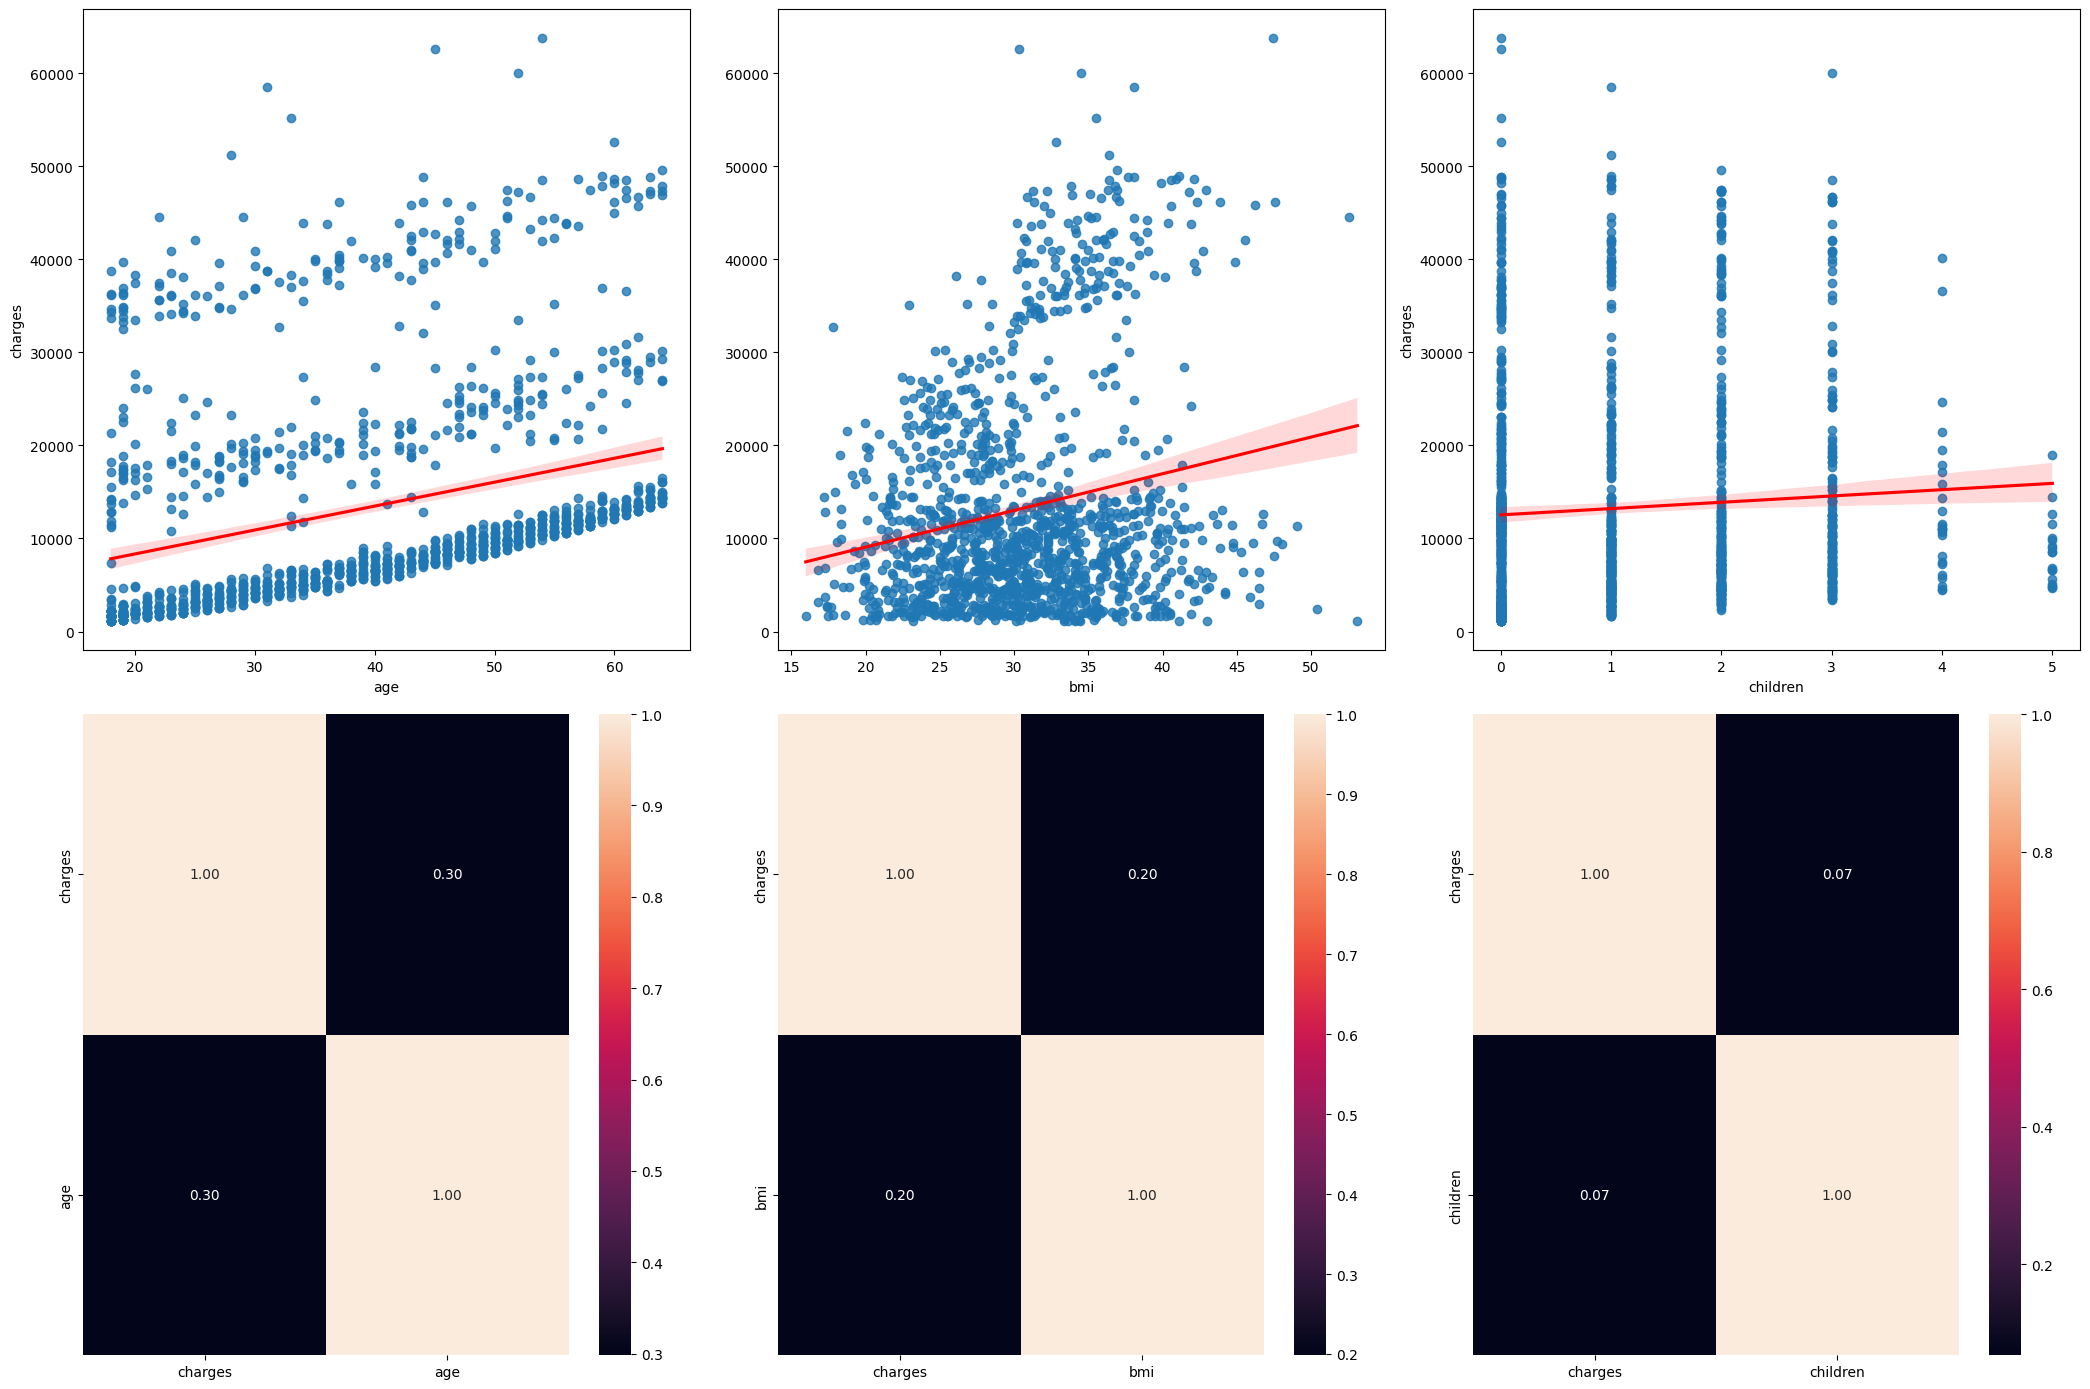

In [44]:
fig, axis = plt.subplots(2, 3, figsize=(21, 14))

sns.regplot(ax=axis[0, 0], data=df, x="age", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 0], data=corr_charges_age, annot=True, fmt=".2f")
sns.regplot(ax=axis[0, 1], data=df, x="bmi", y="charges", line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 1], data=corr_charges_bmi, annot=True, fmt=".2f")
sns.regplot(ax=axis[0, 2], data=df, x="children", y="charges", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1, 2], data=corr_charges_children, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

##### Observaciones - Conclusiones
> Parece que el dato que más influye en el precio de los 3 comparados es la edad, seguido del bmi y con muy poca influencia de los hijos en esta.

>Como el precio es una variable lineal y no categorica la haremos funcionar como esta agrupandola por los tres primeros cuartiles, el cuarto respecto al boxplot con la función Q3 + 1.5 IQR donde el IQR es la diferencia entre el valor del primer cuartil y el tercero, dejando una quinta categoría para los Outliers. (Obtendremos los tres primeros cuartiles de la tabla anteriormente hecha con df.describe().T). Lo haremos creando la categoria price_categorized gracias a la funcion de pandas cut.

In [45]:
Q1 = np.percentile(df['charges'], 25)
Q2 = np.percentile(df['charges'], 50)
Q3 = np.percentile(df['charges'], 75)
Q4_= Q3 + (Q3 - Q1) * 1.5
max_charge = df['charges'].max()
Q1, Q2, Q3, Q4_, max_charge

(np.float64(4746.344),
 np.float64(9386.1613),
 np.float64(16657.71745),
 np.float64(34524.777625),
 np.float64(63770.42801))

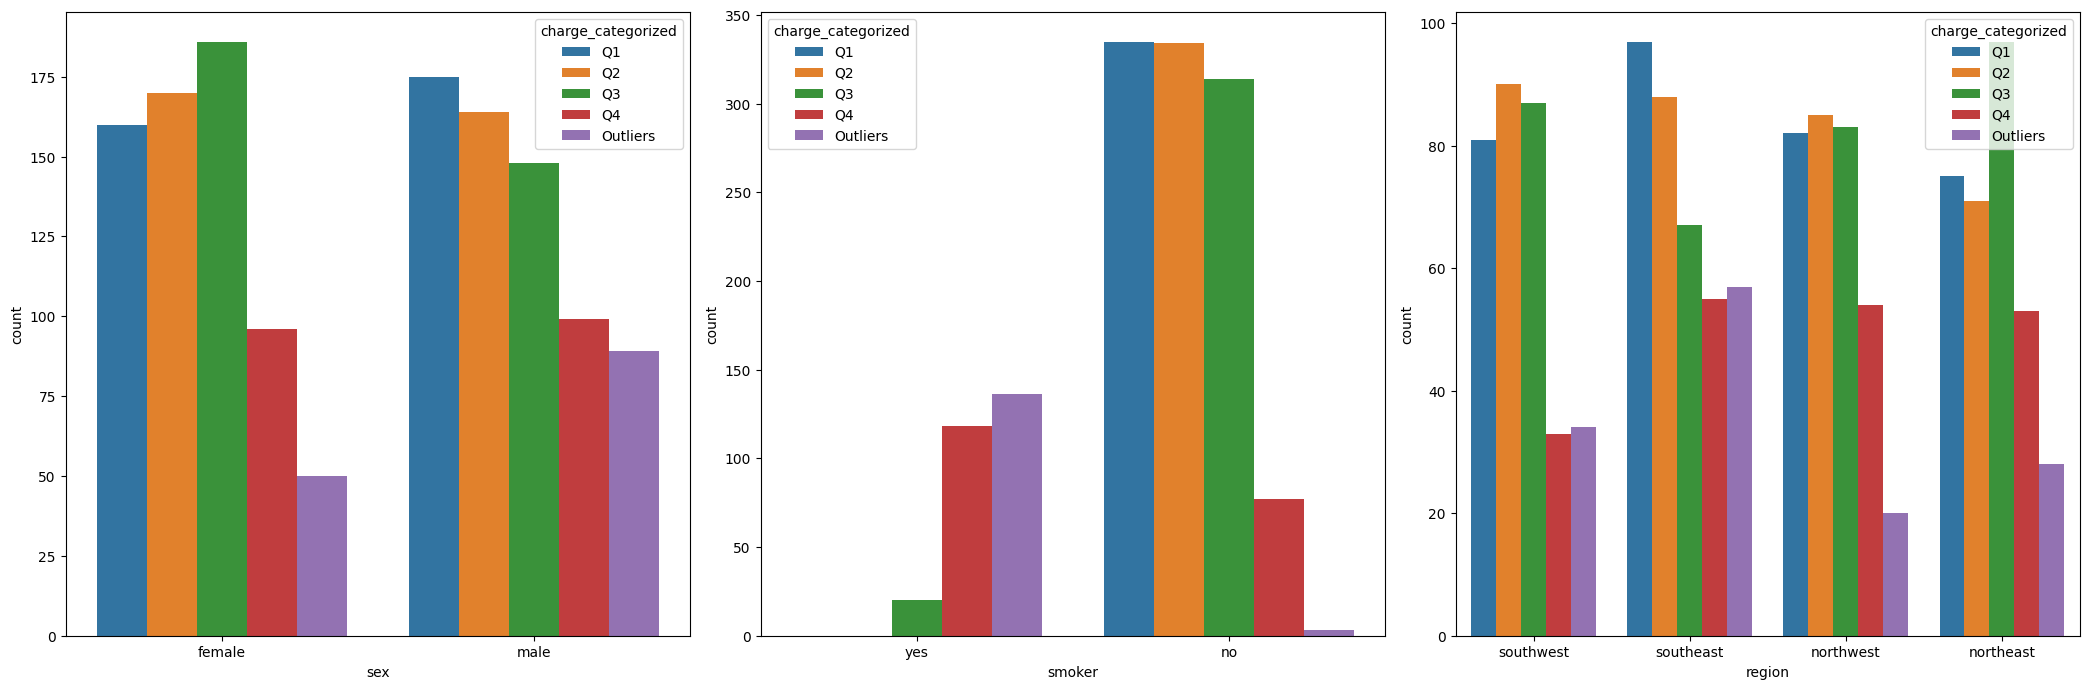

In [46]:
df['charge_categorized'] = pd.cut(df['charges'], bins=[0, Q1, Q2, Q3, Q4_, max_charge], 
                                 labels=['Q1', 'Q2', 'Q3', 'Q4', 'Outliers'])

fig, axs = plt.subplots(1, 3, figsize=(21,7))
sns.countplot(ax=axs[0], data=df, x="sex", hue='charge_categorized')
sns.countplot(ax=axs[1], data=df, x="smoker", hue='charge_categorized')
sns.countplot(ax=axs[2], data=df, x="region", hue='charge_categorized')
plt.tight_layout()
plt.show()

df.drop('charge_categorized', axis=1, inplace=True)

##### Observaciones - Conclusiones
>El sexo parece un factor que influye en el precio levemente al haber más casos de mujeres con precios más baratos que en hombres, aunque de manera leve, en cambio en el caso de fumar es un factor claramente influyente ya que vemos que los clientes fumadores tienen precios más caros casi acaparando el total de los outliers, el factor de la región podría influir levemente también ya que por zonas vemos distribuciones algo diferentes de los tramos de precio.

### Análisis Numérico Categórico completo

>Generamos versiones numericas de las categóricas

In [47]:
df["sex_n"] = pd.factorize(df["sex"])[0]
df["smoker_n"] = pd.factorize(df["smoker"])[0]
df["region_n"] = pd.factorize(df["region"])[0]

>Graficamos entonces con estas y las anteriores las relaciones entre todas las caracteristicas

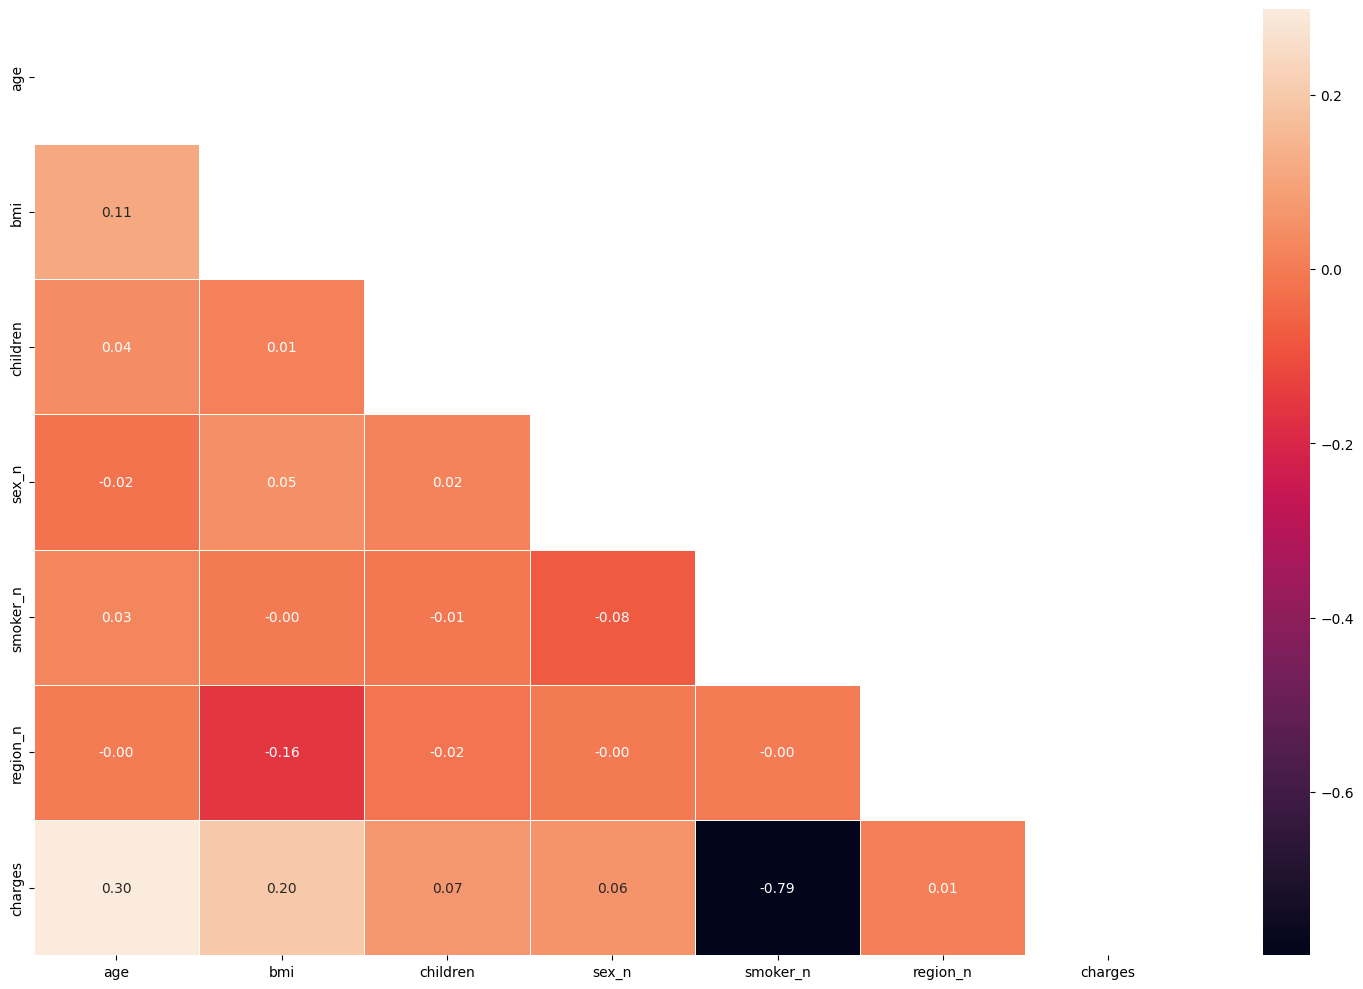

In [48]:
corr = df[['age', 'bmi', 'children', 'sex_n', 
           'smoker_n', 'region_n', 'charges']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

##### Observaciones - Conclusiones
>Vemos una clara correlación entre smoker y charges, además de unas pequeñas relaciones con edad y bmi en ese orden.

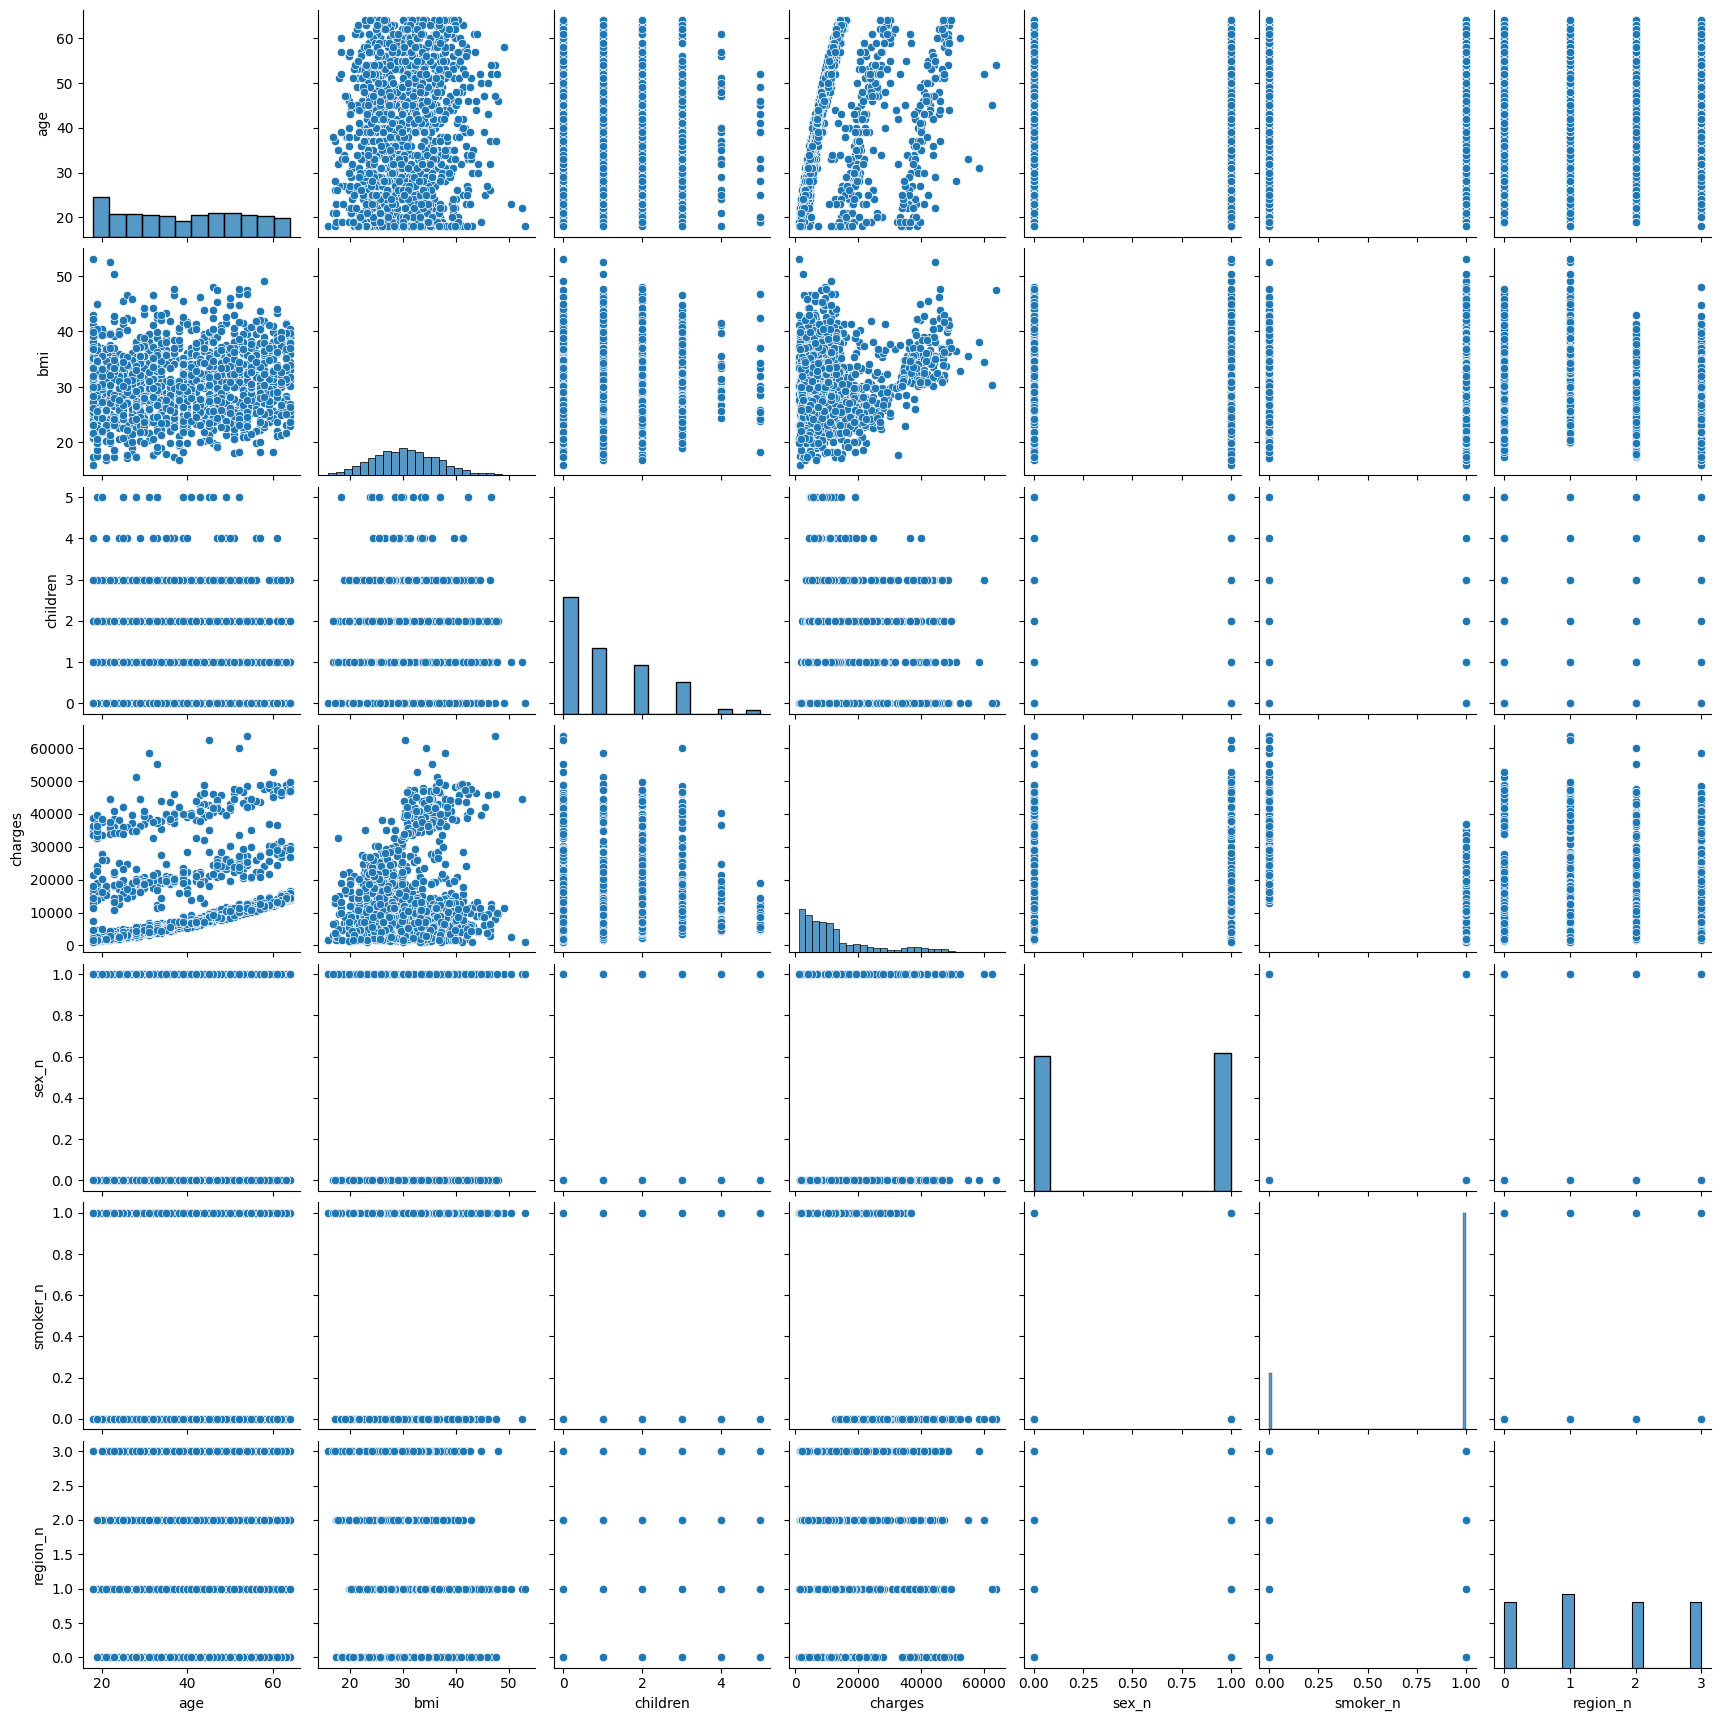

In [49]:
sns.pairplot(data=df)

## Ingeniería de Caracteristicas

### Outliers

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801
sex_n,1337.0,0.504862,0.500163,0.0000,0.000,1.0000,1.00000,1.00000
smoker_n,1337.0,0.795064,0.403806,0.0000,1.000,1.0000,1.00000,1.00000
region_n,1337.0,1.483919,1.105208,0.0000,1.000,1.0000,2.00000,3.00000


##### Observaciones - Conclusiones
>Para ver los Outliers posibles de los datos compararemos las medianas (percentil 50) con las medias y también veremos cuanto se alejan máximos y minimos de percentiles 75 y 25 respectivamente.

>'age', 'bmi', 'children' y 'region' no parecen tener outliers a simple vista, 'sex_n' y 'smoker' puede que tengan algunos valores outlier, la columna que vemos con más outliers es la variable objetivo 'charges'

<function matplotlib.pyplot.show(close=None, block=None)>

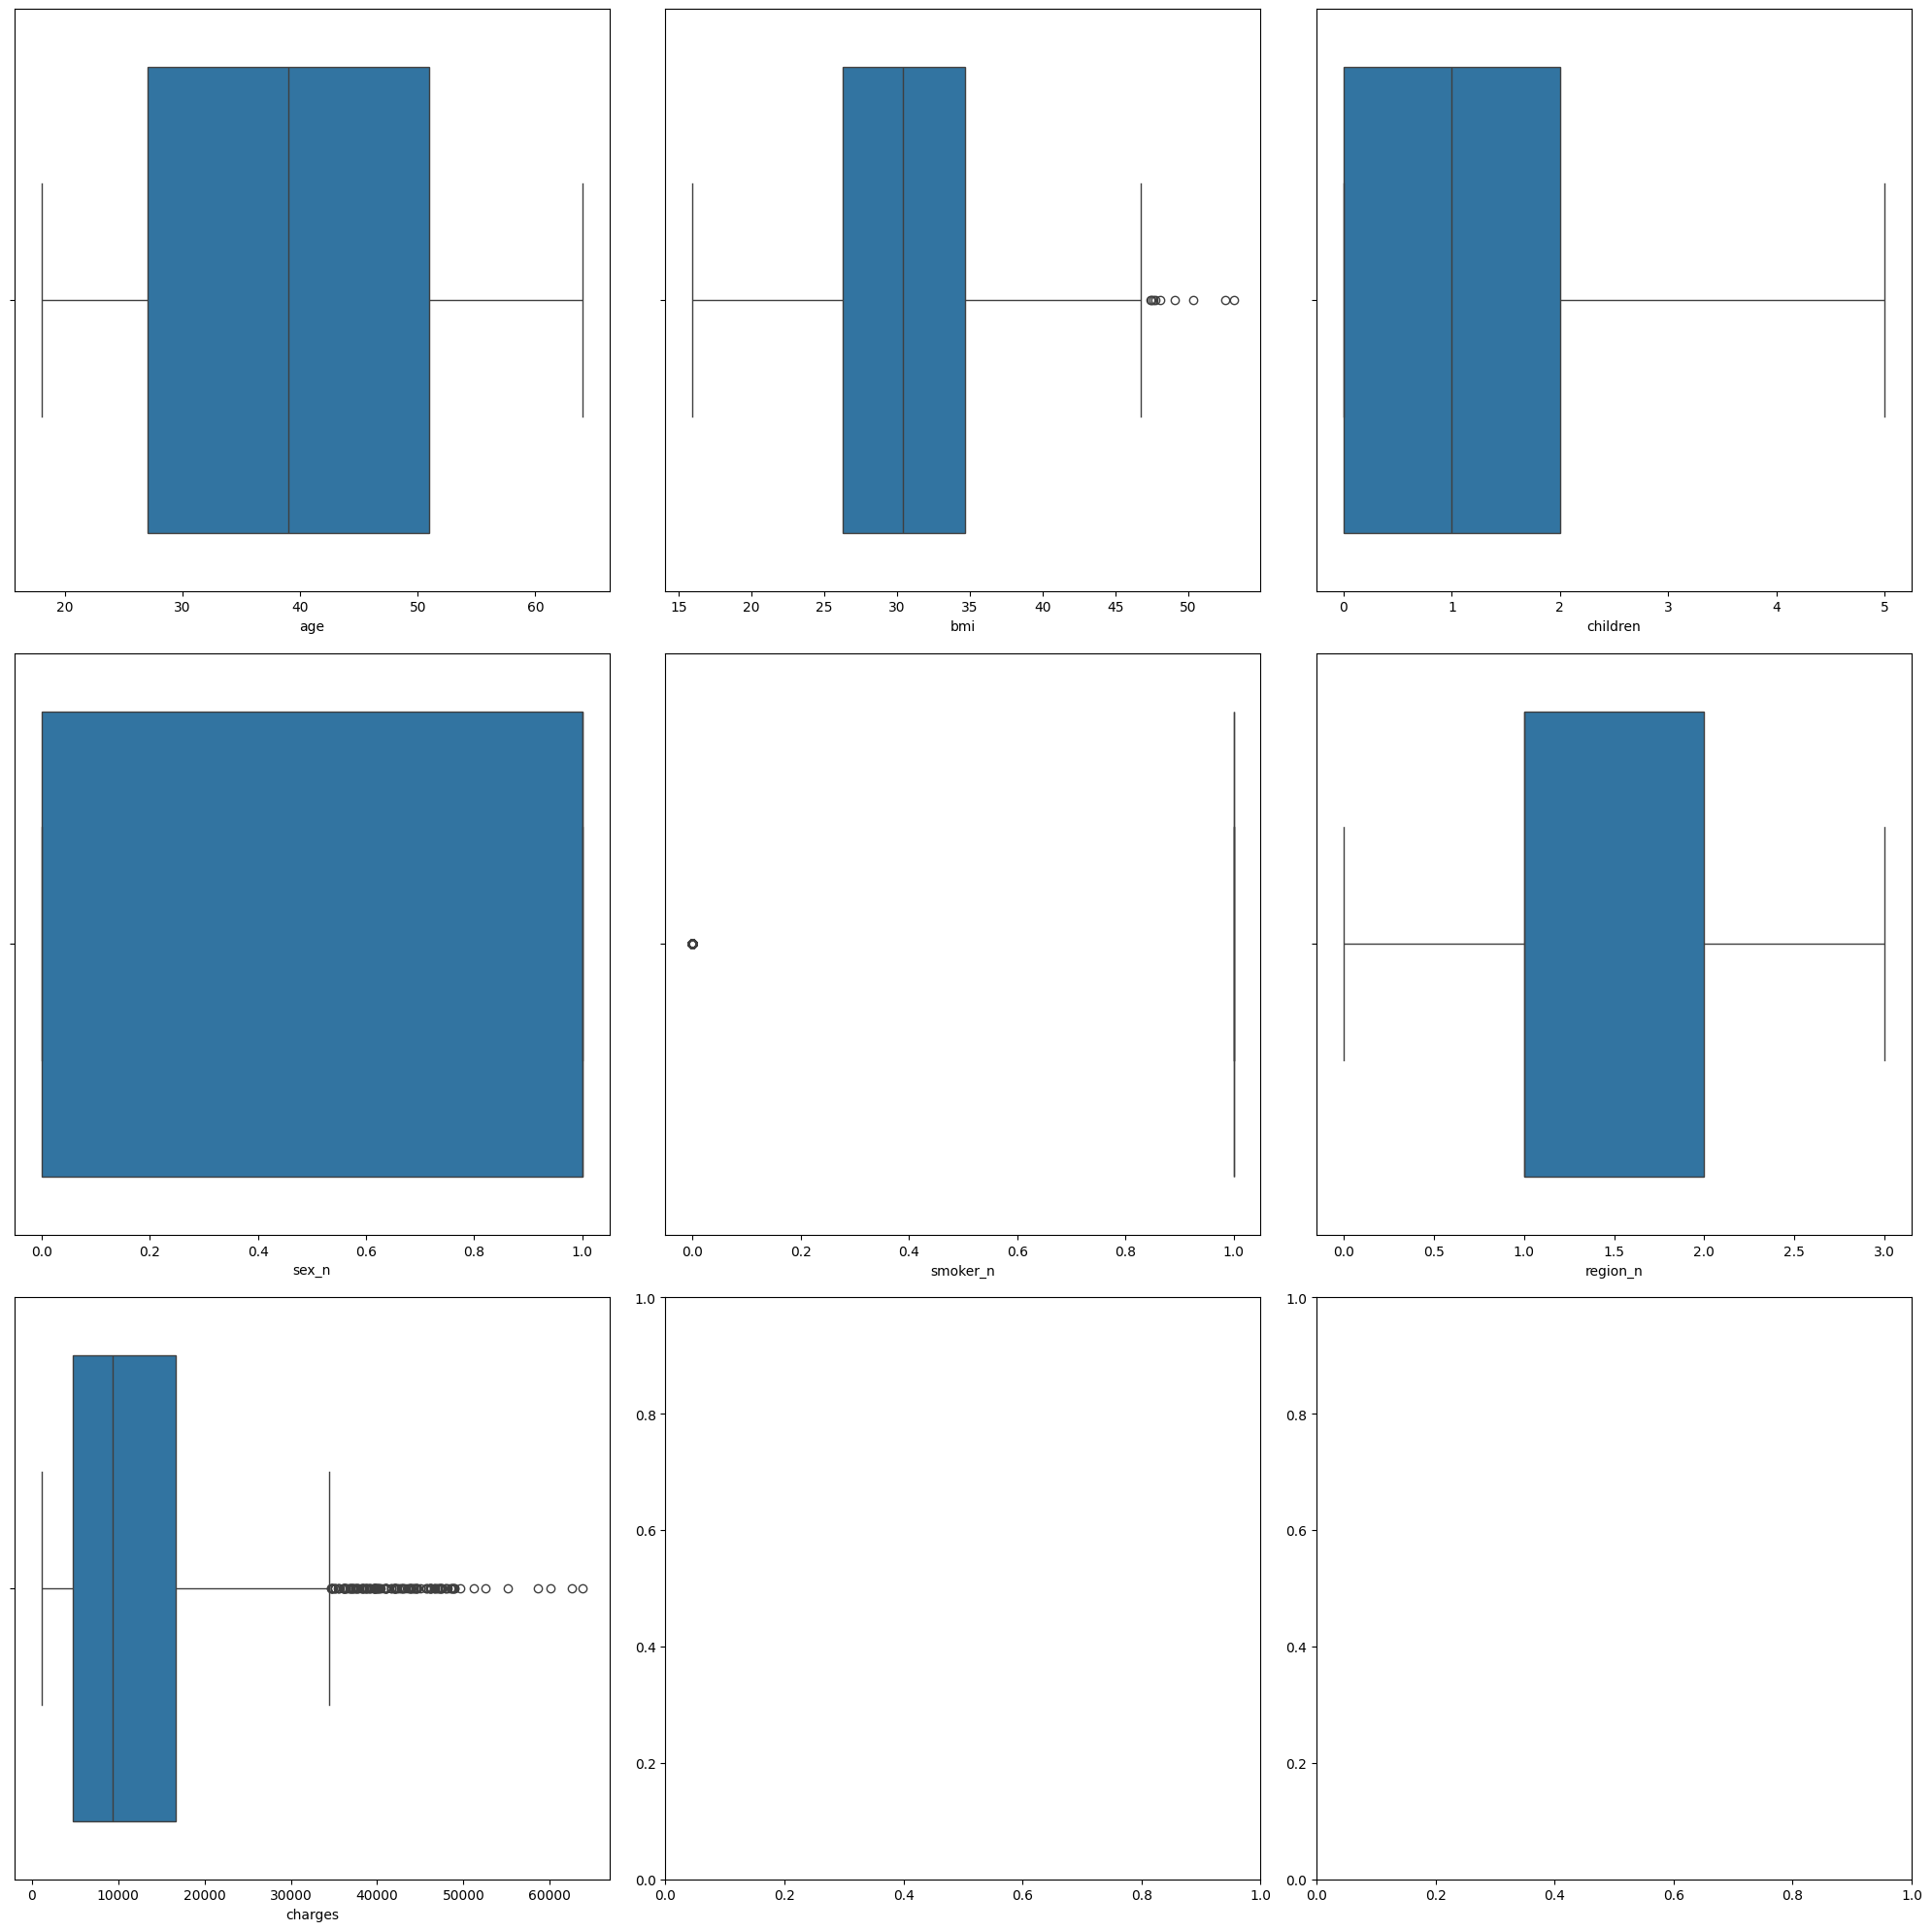

In [51]:
fig, axis = plt.subplots(3, 3, figsize=(20, 20))


sns.boxplot(ax=axis[0, 0], data=df, x="age")
sns.boxplot(ax=axis[0, 1], data=df, x="bmi")
sns.boxplot(ax=axis[0, 2], data=df, x="children")
sns.boxplot(ax=axis[1, 0], data=df, x="sex_n")
sns.boxplot(ax=axis[1, 1], data=df, x="smoker_n")
sns.boxplot(ax=axis[1, 2], data=df, x="region_n")
sns.boxplot(ax=axis[2, 0], data=df, x="charges")

plt.tight_layout()
plt.show

##### Observaciones - Conclusiones
>Vemos en los Boxplot outliers por la derecha en 'bmi' y por la izquierda en 'smoker_n' (esto se debe a una gran mayoría de los clientes son no fumadores pero hay escepciones que si y por ello se generan outliers).

>El elemento con más outliers es 'charges' que es la variable objetivo, esto puede darse a muchos precios que se saldrian de lo normal, quizá generado por los fumadores.

### Faltantes

In [52]:
df.isnull().sum() / df.shape[0]

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
sex_n       0.0
smoker_n    0.0
region_n    0.0
dtype: float64

In [53]:
df.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
sex_n       0
smoker_n    0
region_n    0
dtype: int64

##### Observaciones - Conclusiones
>Podemos observar con las dos funciones que acabamos de usar que no hay ningun valor faltante que haya que solucionar o rellenar de ninguna manera.

### Inferencia de nuevas características
>No veo caracteristicas que se puedan generar correlacionando las que tenemos ahora.

## Split

>Antes de hacer el split voy a volver a limpiar el DataFrame para dejarlo con los datos importantes y sin los datos de apoyo o supletorios que he usado hasta ahora.

In [54]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'sex_n',
       'smoker_n', 'region_n'],
      dtype='object')

In [55]:
df.drop(['sex_n', 'smoker_n', 'region_n'], axis=1, inplace=True)

>Ahora si que hacemos el split definitivo con una semilla de 25.

In [56]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=25)

## Scaling & Encoding

### Encoding
>En este caso solo usaré onehot encoding porque las pocas variables que hay categoricas tienen muy pocos valores distintos. Una vez hecho dropearemos las columnas innecesarias.

In [57]:
onehot_encoder = OneHotEncoder(sparse_output=False)

categoric_categories = ['sex', 'smoker', 'region']

onehot_encoder.fit(X_train[categoric_categories])

X_train_ohe = onehot_encoder.transform(X_train[categoric_categories])
X_train_ohe_df = pd.DataFrame(X_train_ohe,
                              index=X_train.index,
                              columns=onehot_encoder.get_feature_names_out(categoric_categories))

X_test_ohe = onehot_encoder.transform(X_test[categoric_categories])
X_test_ohe_df = pd.DataFrame(X_test_ohe,
                             index=X_test.index,
                             columns=onehot_encoder.get_feature_names_out(categoric_categories))

X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
X_test = pd.concat([X_test, X_test_ohe_df], axis=1)

X_train.drop(['sex', 'smoker', 'region', 'sex_male', 'smoker_no', 'region_southwest'], axis=1, inplace=True)
X_test.drop(['sex', 'smoker', 'region', 'sex_male', 'smoker_no', 'region_southwest'], axis=1, inplace=True)

X_train.head()

,age,bmi,children,sex_female,smoker_yes,region_northeast,region_northwest,region_southeast
630,53,36.100,1,0.0,0.0,0.0,0.0,0.0
556,46,33.440,1,0.0,0.0,1.0,0.0,0.0
427,18,29.165,0,1.0,0.0,1.0,0.0,0.0
1179,31,29.810,0,0.0,1.0,0.0,0.0,1.0
98,56,19.950,0,0.0,1.0,1.0,0.0,0.0


### Scaling

>Como no hemos eliminado los outliers, aunque solo tengamos una columna con estos vamos a usar igualmente robust scaler.

In [58]:
robust_scaler = RobustScaler()

robust_scaler_train = robust_scaler.fit_transform(X_train)
robust_scaler_test = robust_scaler.transform(X_test)

X_train = pd.DataFrame(robust_scaler_train, 
                             columns=X_train.columns,
                             index=X_train.index)

X_test = pd.DataFrame(robust_scaler_test, 
                            columns=X_test.columns,
                            index=X_test.index)

X_train.head()

,age,bmi,children,sex_female,smoker_yes,region_northeast,region_northwest,region_southeast
630,0.56,0.725816,0.0,0.0,0.0,0.0,0.0,0.0
556,0.28,0.398028,0.0,0.0,0.0,1.0,0.0,0.0
427,-0.84,-0.128774,-0.5,1.0,0.0,1.0,0.0,0.0
1179,-0.32,-0.049291,-0.5,0.0,1.0,0.0,0.0,1.0
98,0.68,-1.264325,-0.5,0.0,1.0,1.0,0.0,0.0


### Guardado de Encodings y Scalings

In [ ]:
with open('/workspaces/adamcn10-intro-ml/models/linear-regression-onehot-encoder.pkl', 'wb') as file:
    pickle.dump(onehot_encoder, file)

with open('/workspaces/adamcn10-intro-ml/models/linear-regression-robust-scaler.pkl', 'wb') as file:
    pickle.dump(robust_scaler, file)        

## Modelado

>Creamos el modelo y lo entrenamos

In [62]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


>Después del proceso de entrenamiento podemos conocer los parámetros que ha ajustado el modelo:

In [ ]:
intercept = model.intercept_
coefficient =  model.coef_[0]

intercept, coefficient

(np.float64(7765.071086637957), np.float64(6350.37759017788))

>r2 score

In [64]:
model.score(X_train, y_train)

0.7478591161571652

>Prediccion del modelo

In [67]:
y_pred = model.predict(X_test)
y_pred

array([ 1.18208495e+04,  1.40631916e+04,  9.59993437e+03,  3.05138845e+04,
        3.20246374e+04,  2.87723658e+03,  8.39677877e+03,  8.67648079e+03,
        1.37944414e+04,  1.22125589e+04,  6.33037137e+03,  1.01966698e+04,
       -1.69336273e+03,  8.15355844e+03,  5.60774858e+03,  5.36243226e+03,
        2.76789346e+04,  1.28413753e+04,  4.20752987e+03,  2.86949950e+04,
        1.04196361e+04,  2.73319767e+04,  8.45808480e+03,  1.40284634e+04,
        1.60220361e+04,  1.43799994e+04,  1.04907789e+04,  7.50333131e+03,
        3.54793498e+03,  1.72864728e+04,  1.05230011e+04,  2.77864182e+04,
        1.03556306e+04,  1.09952374e+04,  1.62241071e+04,  3.57650671e+04,
        1.04734581e+04,  2.97998441e+04,  1.14657771e+04,  3.63253613e+04,
        3.85881651e+03,  3.55210345e+04,  4.59978456e+03,  6.31115997e+03,
        3.42082482e+04,  3.01621945e+03,  3.47162329e+03,  3.74600766e+04,
        3.67079802e+04,  3.06877927e+03,  1.15638692e+01,  1.47674764e+04,
        3.21981161e+04,  

In [69]:
y_test

748      8556.90700
634      9391.34600
652      8280.62270
411     19594.80965
502     22218.11490
           ...     
332     13429.03540
893     44202.65360
737      3484.33100
646      6123.56880
1111    41949.24410
Name: charges, Length: 268, dtype: float64

## Evaluación del modelo

In [70]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),
           'RMSE': root_mean_squared_error(y_test, y_pred),
           'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
           'R^2': r2_score(y_test, y_pred),}

metrics

{'MSE': 35317077.051098645,
 'RMSE': 5942.817265497792,
 'MAPE': 0.4568339801992041,
 'R^2': 0.7604434604305353}

## Optimización del modelo

>La unica opción de optimizar el modelo es quitar caracteristicas así que probaremos como queda quitando la región

In [71]:
X_train_optimized = X_train.drop(['region_northeast', 'region_northwest', 'region_southeast'], axis=1)
X_test_optimized = X_test.drop(['region_northeast', 'region_northwest', 'region_southeast'], axis=1)

In [75]:
model_optimized = LinearRegression()
model_optimized.fit(X_train_optimized, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
intercept_optimized = model_optimized.intercept_
coefficient_optimized =  model_optimized.coef_[0]

intercept_optimized, coefficient_optimized

(np.float64(8125.618648139273), np.float64(6398.954486414949))

In [77]:
model_optimized.score(X_train_optimized, y_train)

0.745887288794211

In [78]:
y_pred_optimized = model_optimized.predict(X_test_optimized)
y_pred_optimized

array([ 1.20331589e+04,  1.42063199e+04,  1.02956297e+04,  3.01993510e+04,
        3.29104948e+04,  2.29503591e+03,  9.13517753e+03,  9.58752242e+03,
        1.44009047e+04,  1.14619080e+04,  6.67706518e+03,  9.70404021e+03,
       -1.10032026e+03,  8.53372401e+03,  6.01042057e+03,  5.08945808e+03,
        2.79153120e+04,  1.22476556e+04,  4.75605147e+03,  2.89391447e+04,
        1.10936802e+04,  2.81661163e+04,  7.83369956e+03,  1.42804098e+04,
        1.65045356e+04,  1.35898154e+04,  1.08753207e+04,  7.09743219e+03,
        2.95757096e+03,  1.66057179e+04,  9.98633004e+03,  2.79456800e+04,
        1.07137033e+04,  1.03519814e+04,  1.54767329e+04,  3.52953513e+04,
        1.09748559e+04,  3.00334111e+04,  1.09512879e+04,  3.58250299e+04,
        4.45392774e+03,  3.60208949e+04,  3.95525925e+03,  5.91795453e+03,
        3.36497982e+04,  2.60565368e+03,  3.03222506e+03,  3.69779270e+04,
        3.71939737e+04,  3.63937574e+03,  8.33805994e+02,  1.40775708e+04,
        3.16757887e+04,  

In [79]:
y_test

748      8556.90700
634      9391.34600
652      8280.62270
411     19594.80965
502     22218.11490
           ...     
332     13429.03540
893     44202.65360
737      3484.33100
646      6123.56880
1111    41949.24410
Name: charges, Length: 268, dtype: float64

In [80]:
metrics_optimized = {'MSE': (mean_squared_error(y_test, y_pred), mean_squared_error(y_test, y_pred_optimized)),
           'RMSE': (root_mean_squared_error(y_test, y_pred), root_mean_squared_error(y_test, y_pred_optimized)),
           'MAPE' : (mean_absolute_percentage_error(y_test, y_pred), mean_absolute_percentage_error(y_test, y_pred_optimized)),
           'R^2': (r2_score(y_test, y_pred), r2_score(y_test, y_pred_optimized)),}

metrics_optimized

{'MSE': (35317077.051098645, 34828846.70076648),
 'RMSE': (5942.817265497792, 5901.596961905013),
 'MAPE': (0.4568339801992041, 0.4562596835936379),
 'R^2': (0.7604434604305353, 0.7637551380382019)}

##### Observaciones - Conclusiones
> Viendo todas las métricas, el modelo optimizado es mejor que el original en todas.

## Guardado de Modelos

In [81]:
with open('/workspaces/adamcn10-intro-ml/models/linear-regression-first-model.pkl', 'wb') as file:
    pickle.dump(model, file)

with open('/workspaces/adamcn10-intro-ml/models/linear-regression-optimized-model.pkl', 'wb') as file:
    pickle.dump(model_optimized, file)        